In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

df = pd.read_csv("/kaggle/input/financial-transactions-dataset-for-fraud-detection/financial_fraud_detection_dataset.csv")

/kaggle/input/financial-transactions-dataset-for-fraud-detection/financial_fraud_detection_dataset.csv


In [2]:
import seaborn as sns
import polars as pl
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings("ignore") 

In [3]:
#The first 5 data from the dataset
df.head()

,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash
0,T100000,2023-08-22T09:22:43.516168,ACC877572,ACC388389,343.78,withdrawal,utilities,Tokyo,mobile,False,NaN,NaN,-0.21,3,0.22,card,13.101.214.112,D8536477
1,T100001,2023-08-04T01:58:02.606711,ACC895667,ACC944962,419.65,withdrawal,online,Toronto,atm,False,NaN,NaN,-0.14,7,0.96,ACH,172.52.47.194,D2622631
2,T100002,2023-05-12T11:39:33.742963,ACC733052,ACC377370,2773.86,deposit,other,London,pos,False,NaN,NaN,-1.78,20,0.89,card,185.98.35.23,D4823498
3,T100003,2023-10-10T06:04:43.195112,ACC996865,ACC344098,1666.22,deposit,online,Sydney,pos,False,NaN,NaN,-0.60,6,0.37,wire_transfer,107.136.36.87,D9961380
4,T100004,2023-09-24T08:09:02.700162,ACC584714,ACC497887,24.43,transfer,utilities,Toronto,mobile,False,NaN,NaN,0.79,13,0.27,ACH,108.161.108.255,D7637601


In [4]:
#Display basic info of the dataset
print("Display Info: \n")
print(df.info())

Display Info: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 18 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   transaction_id               object 
 1   timestamp                    object 
 2   sender_account               object 
 3   receiver_account             object 
 4   amount                       float64
 5   transaction_type             object 
 6   merchant_category            object 
 7   location                     object 
 8   device_used                  object 
 9   is_fraud                     bool   
 10  fraud_type                   object 
 11  time_since_last_transaction  float64
 12  spending_deviation_score     float64
 13  velocity_score               int64  
 14  geo_anomaly_score            float64
 15  payment_channel              object 
 16  ip_address                   object 
 17  device_hash                  object 
dtypes: bool(1), float64(4), in

In [5]:
#Check for missing value
print(f"Shape of dataset: {df.shape}")
print(f"The amount of missing value: {df.isnull().sum()}")

Shape of dataset: (5000000, 18)
The amount of missing value: transaction_id                       0
timestamp                            0
sender_account                       0
receiver_account                     0
amount                               0
transaction_type                     0
merchant_category                    0
location                             0
device_used                          0
is_fraud                             0
fraud_type                     4820447
time_since_last_transaction     896513
spending_deviation_score             0
velocity_score                       0
geo_anomaly_score                    0
payment_channel                      0
ip_address                           0
device_hash                          0
dtype: int64


In [6]:
#Class distribution
fraud_trans_count = df["is_fraud"] == True
legit_trans_count = df["is_fraud"] == False
print(f"Fraud transactions: {fraud_trans_count.sum()} ({fraud_trans_count.sum()*100/df.shape[0]:.2f}%)")
print(f"Legitimate transactions: {legit_trans_count.sum()} ({legit_trans_count.sum()*100/df.shape[0]:.2f}%)")

Fraud transactions: 179553 (3.59%)
Legitimate transactions: 4820447 (96.41%)


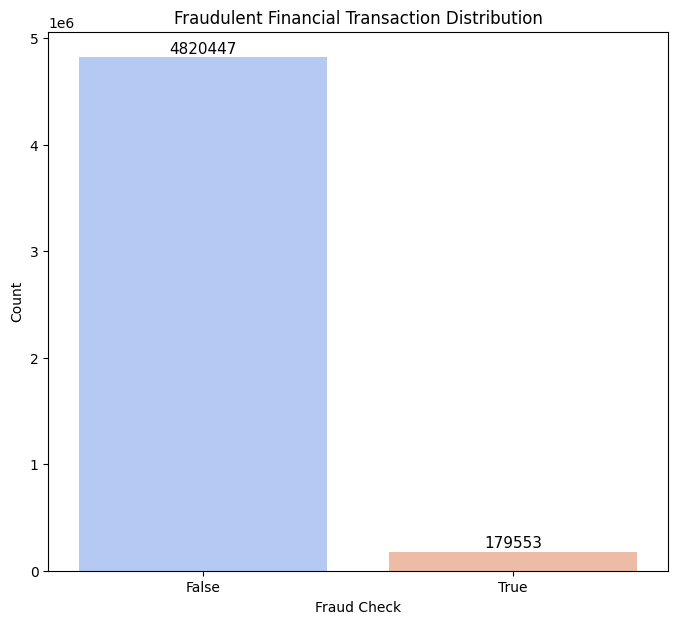

In [7]:
plt.figure(figsize=(8,7))
ax = sns.countplot(x='is_fraud',data=df,palette='coolwarm')
plt.title("Fraudulent Financial Transaction Distribution")
plt.xlabel("Fraud Check")
plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                fontsize=11, color='black',
                xytext=(0, 6),textcoords='offset points')
plt.show()

In [8]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["day_of_week"] = df["timestamp"].dt.weekday
df["month"] = df["timestamp"].dt.month

In [9]:
df["is_fraud"] = df["is_fraud"].astype(int)
df.head()

,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,...,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash,hour,day,day_of_week,month
0,T100000,2023-08-22 09:22:43.516168,ACC877572,ACC388389,343.78,withdrawal,utilities,Tokyo,mobile,0,...,-0.21,3,0.22,card,13.101.214.112,D8536477,9.0,22.0,1.0,8.0
1,T100001,2023-08-04 01:58:02.606711,ACC895667,ACC944962,419.65,withdrawal,online,Toronto,atm,0,...,-0.14,7,0.96,ACH,172.52.47.194,D2622631,1.0,4.0,4.0,8.0
2,T100002,2023-05-12 11:39:33.742963,ACC733052,ACC377370,2773.86,deposit,other,London,pos,0,...,-1.78,20,0.89,card,185.98.35.23,D4823498,11.0,12.0,4.0,5.0
3,T100003,2023-10-10 06:04:43.195112,ACC996865,ACC344098,1666.22,deposit,online,Sydney,pos,0,...,-0.60,6,0.37,wire_transfer,107.136.36.87,D9961380,6.0,10.0,1.0,10.0
4,T100004,2023-09-24 08:09:02.700162,ACC584714,ACC497887,24.43,transfer,utilities,Toronto,mobile,0,...,0.79,13,0.27,ACH,108.161.108.255,D7637601,8.0,24.0,6.0,9.0


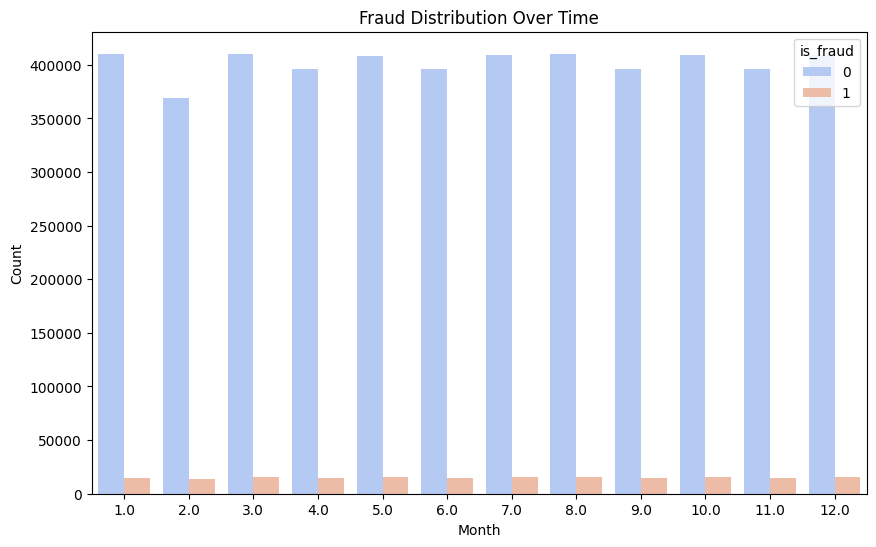

In [10]:
df_pandas = df.sample(n=df.shape[0],random_state = 19)
plt.figure(figsize=(10, 6))  # set figure size first
sns.countplot(x="month", data=df, palette="coolwarm", hue="is_fraud")
plt.title("Fraud Distribution Over Time")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

In [11]:
print(f"Statistic Describe: \n")
df.describe()

Statistic Describe: 



,timestamp,amount,is_fraud,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,hour,day,day_of_week,month
count,4999997,5.000000e+06,5.000000e+06,4.103487e+06,5.000000e+06,5.000000e+06,5.000000e+06,4.999997e+06,4.999997e+06,4.999997e+06,4.999997e+06
mean,2023-07-03 00:10:10.418650112,3.589343e+02,3.591060e-02,1.525799e+00,-3.881160e-04,1.050132e+01,5.000293e-01,1.149665e+01,1.572276e+01,2.999544e+00,6.527235e+00
min,2023-01-01 00:09:26.241974,1.000000e-02,0.000000e+00,-8.777814e+03,-5.260000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00
25%,2023-04-02 17:32:38.758833920,2.657000e+01,0.000000e+00,-2.562376e+03,-6.800000e-01,5.000000e+00,2.500000e-01,5.000000e+00,8.000000e+00,1.000000e+00,4.000000e+00
50%,2023-07-03 01:27:16.670582016,1.386700e+02,0.000000e+00,8.442747e-01,0.000000e+00,1.100000e+01,5.000000e-01,1.100000e+01,1.600000e+01,3.000000e+00,7.000000e+00
75%,2023-10-02 05:43:06.393416960,5.038900e+02,0.000000e+00,2.568339e+03,6.700000e-01,1.600000e+01,7.500000e-01,1.700000e+01,2.300000e+01,5.000000e+00,1.000000e+01
max,2024-01-01 22:58:30.131850,3.520570e+03,1.000000e+00,8.757758e+03,5.020000e+00,2.000000e+01,1.000000e+00,2.300000e+01,3.100000e+01,6.000000e+00,1.200000e+01
std,NaN,4.699333e+02,1.860673e-01,3.576569e+03,1.000807e+00,5.766842e+00,2.886349e-01,6.921329e+00,8.796412e+00,2.003172e+00,3.447722e+00


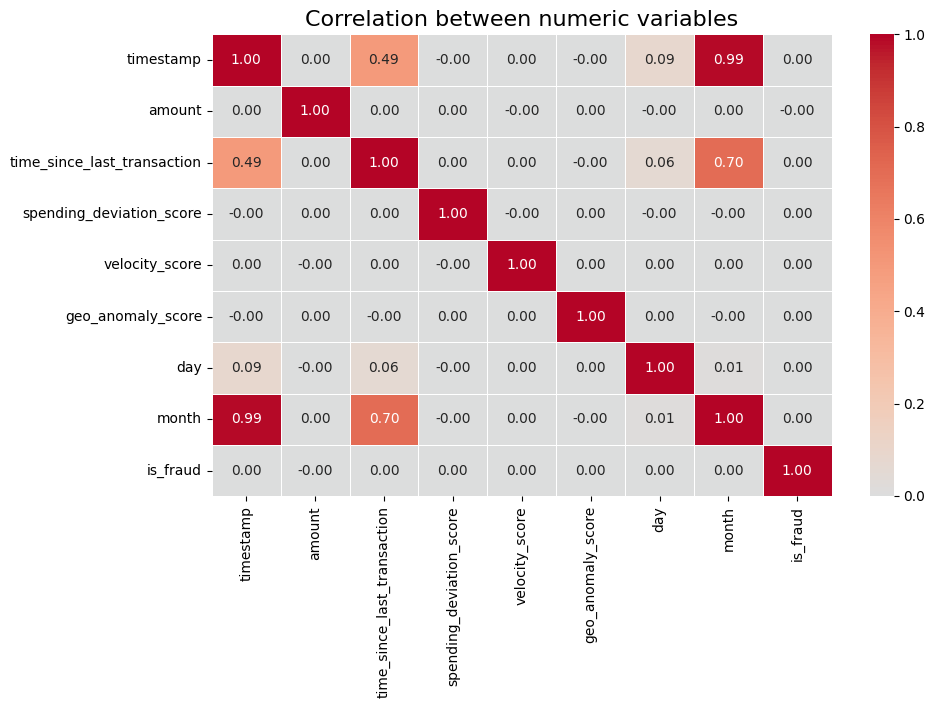

In [12]:
### Correlation for numeric variables
corr_df = df[["timestamp","amount","time_since_last_transaction","spending_deviation_score","velocity_score","geo_anomaly_score","day","month","is_fraud"]]
correlation_matrix = corr_df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',center=0,linewidths=0.5,cbar=True,fmt='.2f')
plt.title("Correlation between numeric variables",fontsize=16)
plt.show()

In [13]:
### Month
fraud_by_month = (
    df.groupby("month")
    .agg(
        total_trans=("is_fraud", "count"),
        fraud_trans=("is_fraud", "sum")
    )
)
fraud_by_month["fraud_rate (%)"] = fraud_by_month["fraud_trans"]*100 / fraud_by_month["total_trans"]
fraud_by_month["fraud_rate (%)"] = fraud_by_month["fraud_rate (%)"].round(2)
fraud_by_month.sort_values("fraud_rate (%)",ascending=False).head(10)

,total_trans,fraud_trans,fraud_rate (%)
month,,,
7.0,424492,15395,3.63
12.0,424558,15376,3.62
10.0,424906,15331,3.61
9.0,411277,14855,3.61
2.0,382551,13777,3.60
6.0,410890,14759,3.59
4.0,411054,14761,3.59
3.0,425454,15247,3.58
11.0,411100,14730,3.58


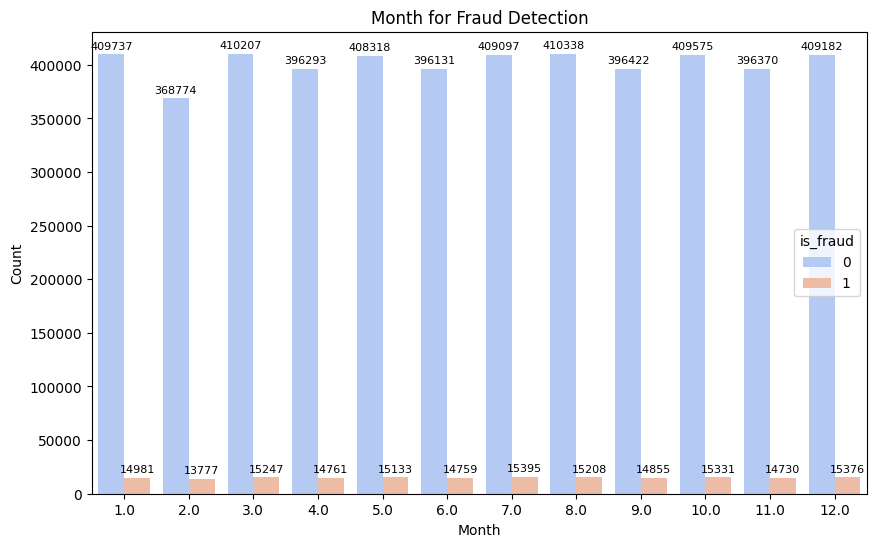

In [14]:
plt.figure(figsize=(10,6))
ax = sns.countplot(x='month',hue='is_fraud',data=df,palette='coolwarm')
plt.title('Month for Fraud Detection')
plt.legend(title='is_fraud',loc='center right')
plt.xlabel('Month')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                fontsize=8, color='black',
                xytext=(0, 6),textcoords='offset points')
plt.show()

In [15]:
### Day
fraud_by_day = (
    df.groupby("day")
    .agg(
        total_trans=("is_fraud", "count"),
        fraud_trans=("is_fraud", "sum")
    )
)
fraud_by_day["fraud_rate (%)"] = fraud_by_day["fraud_trans"]*100 / fraud_by_day["total_trans"]
fraud_by_day["fraud_rate (%)"] = fraud_by_day["fraud_rate (%)"].round(2)
fraud_by_day.sort_values("fraud_rate (%)",ascending=False).head(100)

,total_trans,fraud_trans,fraud_rate (%)
day,,,
9.0,164309,6021,3.66
29.0,150622,5520,3.66
23.0,164134,6010,3.66
8.0,164299,5982,3.64
21.0,165429,6023,3.64
26.0,164901,5983,3.63
28.0,164428,5975,3.63
11.0,163454,5917,3.62
7.0,164035,5930,3.62


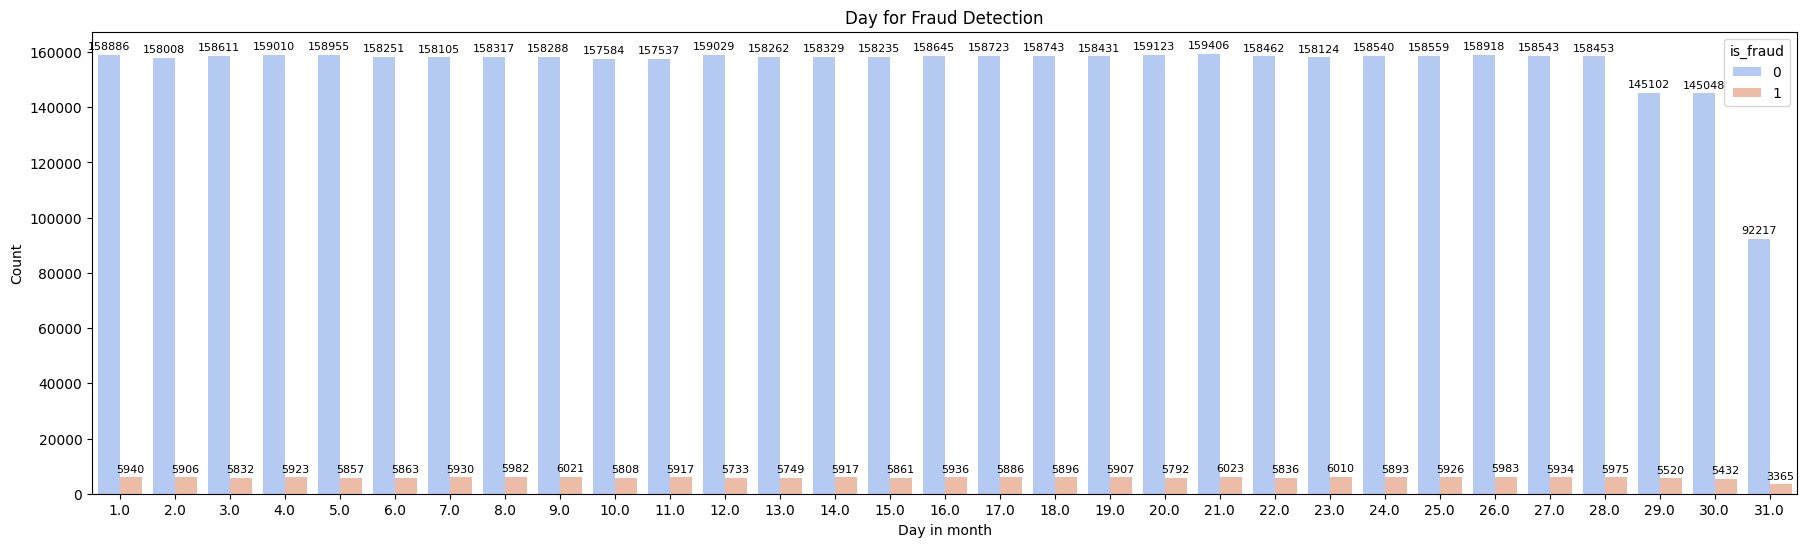

In [16]:
plt.figure(figsize=(22,6))
ax = sns.countplot(x='day',hue='is_fraud',data=df,palette='coolwarm')
plt.title('Day for Fraud Detection')
# plt.legend(title='is_fraud',loc='center right')
plt.xlabel('Day in month')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                fontsize=8, color='black',
                xytext=(0, 6),textcoords='offset points')
plt.show()

In [17]:
# Sender/Receiver
print(f"Number of senders: {np.unique(df['sender_account']).size}")
print(f"Number of receivers: {np.unique(df['receiver_account']).size}")

Number of senders: 896513
Number of receivers: 896639


In [18]:
# Top 10 most active sender in the dataset
df.groupby("sender_account").size().reset_index(name="count").sort_values("count", ascending=False).head(10)

,sender_account,count
880495,ACC983922,20
752113,ACC854997,19
38337,ACC138486,19
759735,ACC862649,19
306713,ACC407908,19
828457,ACC931649,19
239850,ACC340776,18
281565,ACC382656,18
208531,ACC309339,18
662672,ACC765230,18


In [19]:
# Top 10 most active receiver in the dataset
df.groupby("receiver_account").size().reset_index(name="count").sort_values("count",ascending=False).head(10)

,receiver_account,count
299127,ACC400278,23
702040,ACC804655,20
617176,ACC719493,19
889446,ACC992780,19
350954,ACC452312,19
851661,ACC954845,18
814386,ACC917408,18
858008,ACC961218,18
807607,ACC910612,18
478530,ACC580358,18


In [20]:
# Calculate the rate that related to each account
fraud_by_sender = (
    df.groupby("sender_account")
    .agg(
        total_trans=("is_fraud", "count"),
        fraud_trans=("is_fraud", "sum")
    )
)
fraud_by_sender["fraud_rate (%)"] = fraud_by_sender["fraud_trans"]*100 / fraud_by_sender["total_trans"]
fraud_by_sender["fraud_rate (%)"] = fraud_by_sender["fraud_rate (%)"].round(2)
fraud_by_sender.sort_values("fraud_rate (%)",ascending=False).head(10)

,total_trans,fraud_trans,fraud_rate (%)
sender_account,,,
ACC509812,4,3,75.0
ACC578240,4,3,75.0
ACC785965,4,3,75.0
ACC774428,4,3,75.0
ACC921829,4,3,75.0
ACC111101,4,3,75.0
ACC741428,4,3,75.0
ACC952479,4,3,75.0
ACC802400,4,3,75.0


In [21]:
fraud_by_receiver = (
    df.groupby("receiver_account").agg(
        total_trans=('is_fraud','count'),
        fraud_trans=('is_fraud','sum')
    )
)
fraud_by_receiver['fraud_rate (%)'] = fraud_by_receiver['fraud_trans']*100/fraud_by_receiver['total_trans']
fraud_by_receiver['fraud_rate (%)'] = fraud_by_receiver['fraud_rate (%)'].round(2)
fraud_by_receiver.sort_values("fraud_rate (%)",ascending=False).head(10)

,total_trans,fraud_trans,fraud_rate (%)
receiver_account,,,
ACC231348,2,2,100.0
ACC901532,2,2,100.0
ACC292203,2,2,100.0
ACC235471,1,1,100.0
ACC869644,1,1,100.0
ACC676794,1,1,100.0
ACC613635,1,1,100.0
ACC498118,1,1,100.0
ACC220725,1,1,100.0


In [22]:
#### Top 10 most active pair of accounts in the dataset

df.groupby(["sender_account","receiver_account"]).agg(
    total_trans=('is_fraud','count'),
    fraud_trans=('is_fraud','sum')
).sort_values("fraud_trans",ascending=False).head(10)

,,total_trans,fraud_trans
sender_account,receiver_account,,
ACC749215,ACC563606,1,1
ACC897462,ACC640755,1,1
ACC245699,ACC737193,1,1
ACC360523,ACC448543,1,1
ACC313101,ACC612839,1,1
ACC459657,ACC587385,1,1
ACC532015,ACC337529,1,1
ACC749214,ACC207932,1,1
ACC609583,ACC752480,1,1


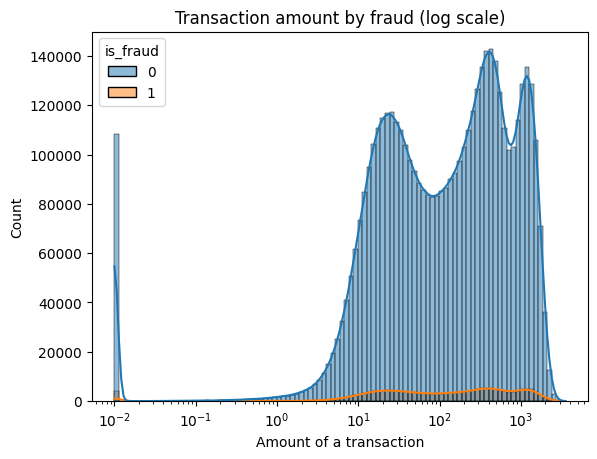

In [23]:
sns.histplot(df,x='amount',hue='is_fraud',bins=100,kde=True,log_scale=True)
plt.xlabel('Amount of a transaction')
plt.title("Transaction amount by fraud (log scale)")
plt.show()

In [24]:
fraud_by_mc = (df.groupby('merchant_category').agg(
    total_trans=('is_fraud','count'),
    fraud_trans=('is_fraud','sum')
))
fraud_by_mc['fraud_rate (%)'] = fraud_by_mc['fraud_trans']*100/fraud_by_mc['total_trans']
fraud_by_mc['fraud_rate (%)']= fraud_by_mc['fraud_rate (%)'].round(2)
fraud_by_mc.sort_values("fraud_rate (%)",ascending=False).head(10)

,total_trans,fraud_trans,fraud_rate (%)
merchant_category,,,
entertainment,625332,22573,3.61
other,624589,22556,3.61
grocery,624954,22516,3.60
travel,625656,22503,3.60
online,623581,22324,3.58
restaurant,625483,22367,3.58
retail,626319,22453,3.58
utilities,624086,22261,3.57


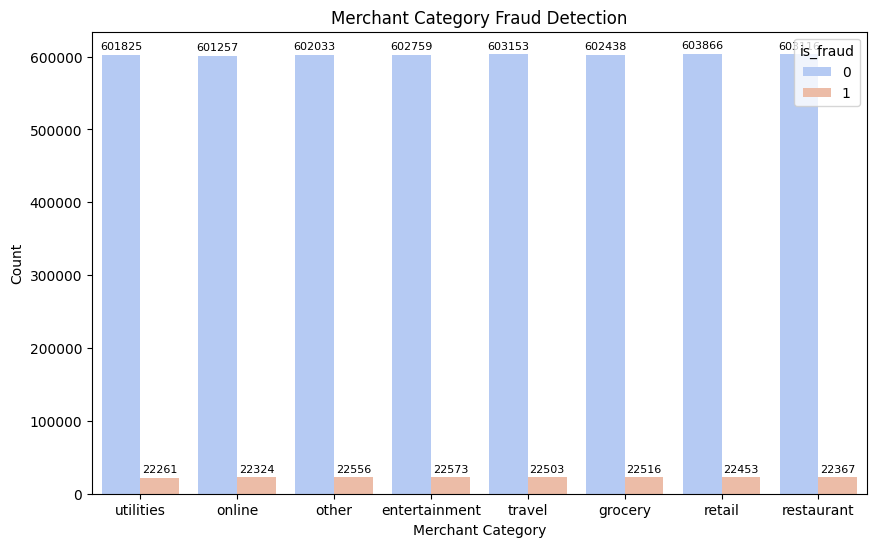

In [25]:
plt.figure(figsize=(10,6))
ax = sns.countplot(x='merchant_category',hue='is_fraud',data=df,palette='coolwarm')
plt.title('Merchant Category Fraud Detection')
plt.xlabel('Merchant Category')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                fontsize=8, color='black',
                xytext=(0, 6),textcoords='offset points')
plt.show()

In [26]:
df.groupby("transaction_type").size().reset_index(name="Count").sort_values("Count",ascending=False).head(10)

,transaction_type,Count
0,deposit,1250593
1,payment,1250438
2,transfer,1250334
3,withdrawal,1248635


In [27]:
#Lets see what fraud most use transaction type
fraud_by_tp = (df.groupby('transaction_type').agg(
    total_trans=('is_fraud','count'),
    fraud_trans=('is_fraud','sum')
))
fraud_by_tp['fraud_rate (%)'] = fraud_by_tp['fraud_trans']*100/fraud_by_tp['total_trans']
fraud_by_tp['fraud_rate (%)']= fraud_by_tp['fraud_rate (%)'].round(2)
fraud_by_tp.sort_values("fraud_rate (%)",ascending=False).head()

,total_trans,fraud_trans,fraud_rate (%)
transaction_type,,,
transfer,1250334,45328,3.63
withdrawal,1248635,44874,3.59
deposit,1250593,44786,3.58
payment,1250438,44565,3.56


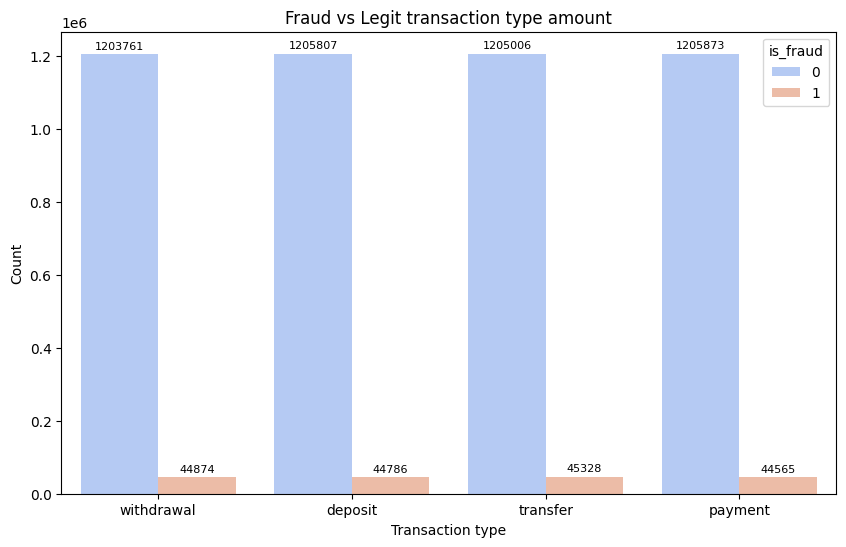

In [28]:
plt.figure(figsize=(10,6))
ax = sns.countplot(x='transaction_type',hue='is_fraud',data=df,palette='coolwarm')
plt.title('Fraud vs Legit transaction type amount')
plt.xlabel('Transaction type')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                fontsize=8, color='black',
                xytext=(0, 6),textcoords='offset points')
plt.show()

In [29]:

fraud_by_sds = (df.groupby("spending_deviation_score").agg(
    total_trans=('is_fraud','count'),
    fraud_trans=('is_fraud','sum')
).sort_values('fraud_trans',ascending=False))
fraud_by_sds['fraud_rate (%)'] = fraud_by_sds['fraud_trans']*100/fraud_by_sds['total_trans']
fraud_by_sds['fraud_rate (%)'] = fraud_by_sds['fraud_rate (%)'].round(2)
fraud_by_sds.head(10)

,total_trans,fraud_trans,fraud_rate (%)
spending_deviation_score,,,
0.15,19779,762,3.85
0.07,19742,759,3.84
0.02,19802,757,3.82
-0.00,20087,756,3.76
-0.11,19903,750,3.77
0.17,19665,747,3.80
-0.23,19558,743,3.80
-0.07,20078,741,3.69
0.29,19052,740,3.88


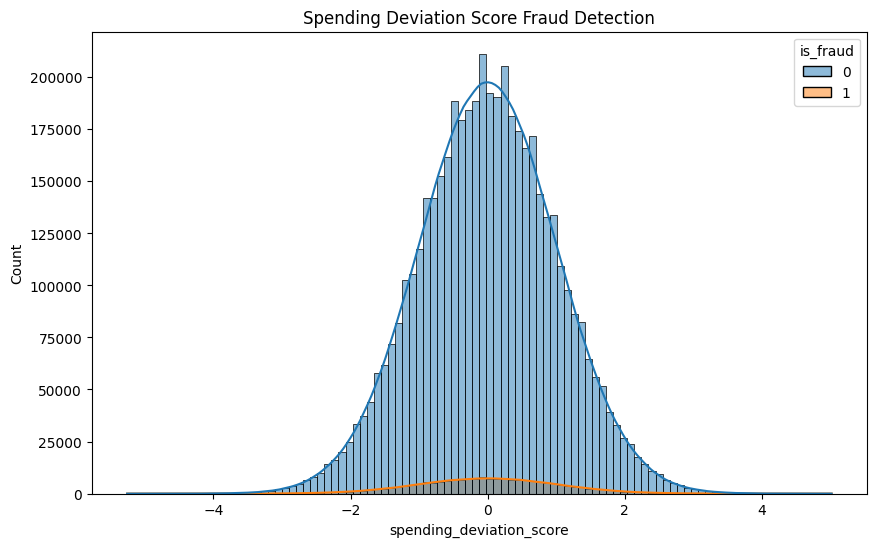

In [30]:
plt.figure(figsize=(10,6))
sns.histplot(data=df,x='spending_deviation_score',hue='is_fraud',bins=100,kde=True)
plt.title("Spending Deviation Score Fraud Detection")
plt.show()

In [31]:
fraud_by_vs = (df.groupby("velocity_score").agg(
    total_trans=('is_fraud','count'),
    fraud_trans=('is_fraud','sum')
))
fraud_by_vs['fraud_rate (%)'] = fraud_by_vs['fraud_trans']*100/fraud_by_vs['total_trans']
fraud_by_vs['fraud_rate (%)'] = fraud_by_vs['fraud_rate (%)'].round(2)
fraud_by_vs.sort_values('fraud_rate (%)',ascending=False).head(10)

,total_trans,fraud_trans,fraud_rate (%)
velocity_score,,,
17,250353,9102,3.64
6,249818,9078,3.63
5,249956,9083,3.63
8,249065,9053,3.63
18,250777,9096,3.63
20,250050,9030,3.61
19,249834,9030,3.61
12,249695,9018,3.61
11,249904,8992,3.60


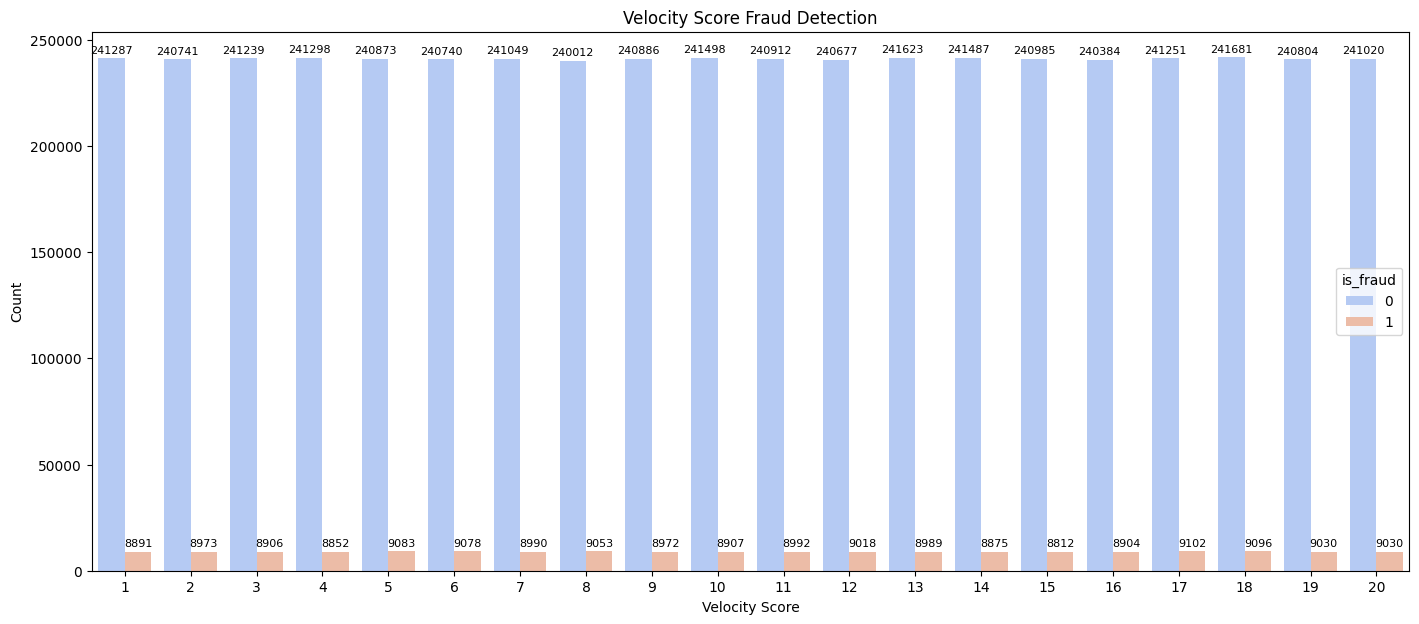

In [32]:
plt.figure(figsize=(17,7))
ax = sns.countplot(data=df,x='velocity_score',hue='is_fraud',palette='coolwarm')
ax.legend(title="is_fraud",loc='center right')
plt.title("Velocity Score Fraud Detection")
plt.xlabel("Velocity Score")
plt.ylabel("Count")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                fontsize=8, color='black',
                xytext=(0, 6),textcoords='offset points')
plt.show()


In [33]:
fraud_by_gas = (df.groupby("geo_anomaly_score").agg(
    total_trans=('is_fraud','count'),
    fraud_trans=('is_fraud','sum')
))
fraud_by_gas['fraud_rate (%)'] = fraud_by_gas['fraud_trans']*100/fraud_by_gas['total_trans']
fraud_by_gas['fraud_rate (%)'] = fraud_by_gas['fraud_rate (%)'].round(2)
fraud_by_gas.sort_values('fraud_rate (%)').head(10)

,total_trans,fraud_trans,fraud_rate (%)
geo_anomaly_score,,,
0.04,50116,1680,3.35
0.68,49850,1692,3.39
0.15,49600,1697,3.42
0.83,49585,1694,3.42
0.67,50384,1734,3.44
0.18,49876,1721,3.45
0.43,50018,1738,3.47
0.47,49951,1731,3.47
0.27,50261,1747,3.48


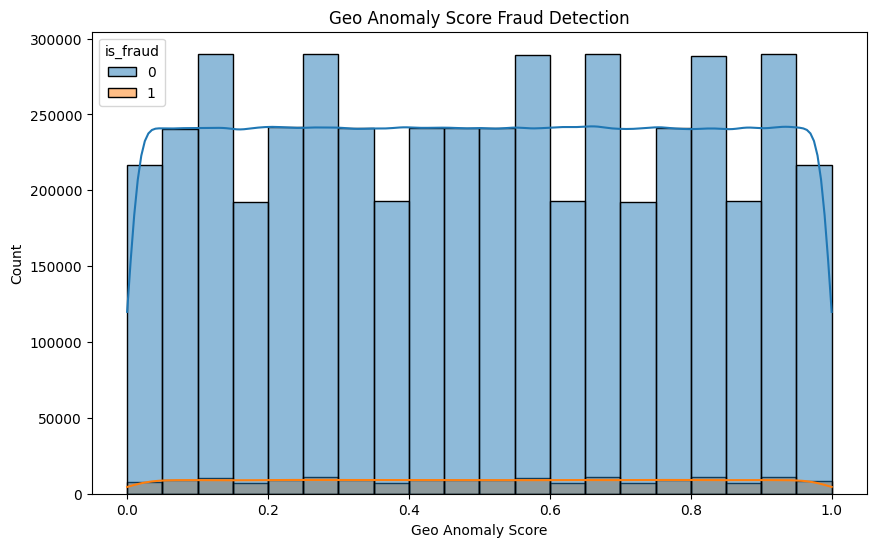

In [34]:
plt.figure(figsize=(10,6))
sns.histplot(data=df,x='geo_anomaly_score',bins=20,hue='is_fraud',kde=True)
plt.title("Geo Anomaly Score Fraud Detection")
plt.xlabel("Geo Anomaly Score")
plt.ylabel("Count")
plt.show()

In [35]:
fraud_by_ip = (df.groupby("ip_address").agg(
    total_trans=('is_fraud','count'),
    fraud_trans=('is_fraud','sum')
))
fraud_by_ip['fraud_rate (%)'] = fraud_by_ip['fraud_trans']*100/fraud_by_ip['total_trans']
fraud_by_ip['fraud_rate (%)'] = fraud_by_ip['fraud_rate (%)'].round(2)
fraud_by_ip.sort_values('fraud_rate (%)',ascending=False).head(10)

,total_trans,fraud_trans,fraud_rate (%)
ip_address,,,
35.45.58.149,1,1,100.0
103.235.138.44,1,1,100.0
122.54.121.66,1,1,100.0
194.252.110.138,1,1,100.0
145.47.73.216,1,1,100.0
248.25.209.19,1,1,100.0
45.174.227.141,1,1,100.0
21.143.47.159,1,1,100.0
171.154.195.161,1,1,100.0


In [36]:
fraud_by_loc = (df.groupby("location").agg(
    total_trans=('is_fraud','count'),
    fraud_trans=('is_fraud','sum')
))
fraud_by_loc['fraud_rate (%)'] = fraud_by_loc['fraud_trans']*100/fraud_by_loc['total_trans']
fraud_by_loc['fraud_rate (%)'] = fraud_by_loc['fraud_rate (%)'].round(2)
fraud_by_loc.sort_values('fraud_rate (%)',ascending=False).head(10)

,total_trans,fraud_trans,fraud_rate (%)
location,,,
London,624256,22478,3.60
Toronto,624349,22501,3.60
New York,625354,22460,3.59
Berlin,625289,22435,3.59
Sydney,625125,22458,3.59
Singapore,625313,22461,3.59
Dubai,624320,22340,3.58
Tokyo,625994,22420,3.58


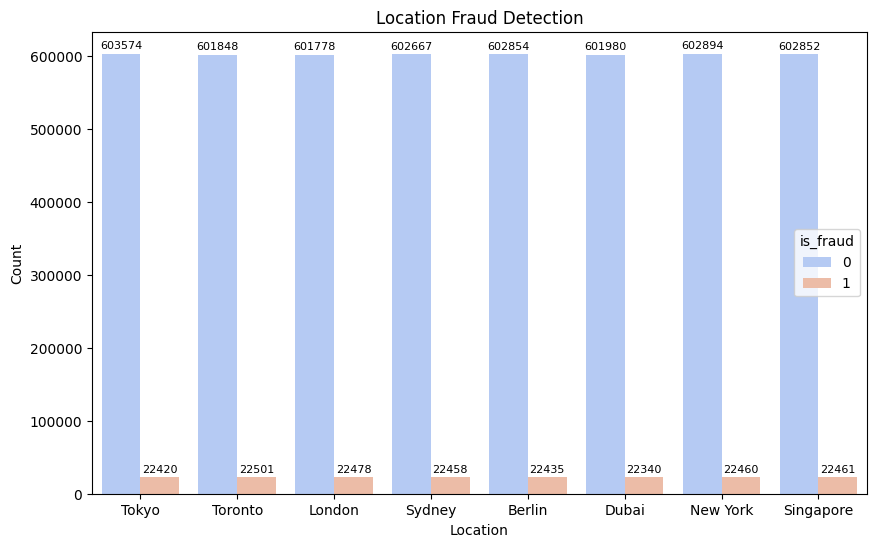

In [37]:
plt.figure(figsize=(10,6))
ax = sns.countplot(x='location',hue='is_fraud',data=df,palette='coolwarm')
plt.title('Location Fraud Detection')
plt.xlabel('Location')
plt.ylabel('Count')
plt.legend(title='is_fraud',loc='center right')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                fontsize=8, color='black',
                xytext=(0, 6),textcoords='offset points')
plt.show()

In [38]:
fraud_by_pc = (df.groupby("payment_channel").agg(
    total_trans=('is_fraud','count'),
    fraud_trans=('is_fraud','sum')
))
fraud_by_pc['fraud_rate (%)'] = fraud_by_pc['fraud_trans']*100/fraud_by_pc['total_trans']
fraud_by_pc['fraud_rate (%)'] = fraud_by_pc['fraud_rate (%)'].round(2)
fraud_by_pc.sort_values('fraud_rate (%)',ascending=False).head(10)

,total_trans,fraud_trans,fraud_rate (%)
payment_channel,,,
wire_transfer,1251219,45034,3.60
UPI,1248847,44896,3.59
card,1249693,44885,3.59
ACH,1250241,44738,3.58


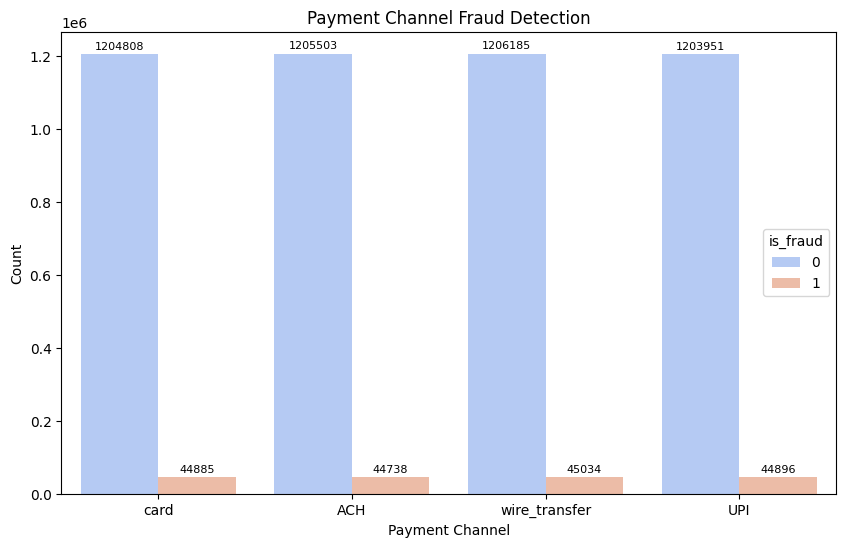

In [39]:
plt.figure(figsize=(10,6))
ax = sns.countplot(x='payment_channel',hue='is_fraud',data=df,palette='coolwarm')
plt.title('Payment Channel Fraud Detection')
plt.xlabel('Payment Channel')
plt.ylabel('Count')
plt.legend(title='is_fraud',loc='center right')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                fontsize=8, color='black',
                xytext=(0, 6),textcoords='offset points')
plt.show()

In [40]:
fraud_by_dh = (df.groupby("device_hash").agg(
    total_trans=('is_fraud','count'),
    fraud_trans=('is_fraud','sum')
))
fraud_by_dh['fraud_rate (%)'] = fraud_by_dh['fraud_trans']*100/fraud_by_dh['total_trans']
fraud_by_dh['fraud_rate (%)'] = fraud_by_dh['fraud_rate (%)'].round(2)
fraud_by_dh.sort_values('fraud_rate (%)',ascending=False).head(10)

,total_trans,fraud_trans,fraud_rate (%)
device_hash,,,
D3042861,1,1,100.0
D2852210,1,1,100.0
D4683239,1,1,100.0
D4763748,1,1,100.0
D9782534,1,1,100.0
D9782536,1,1,100.0
D3042847,1,1,100.0
D3921106,1,1,100.0
D7084794,1,1,100.0


In [41]:
## Library for Data Processing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

In [42]:
#1 Handle Missing values
### time_since_last_spend
imputer = SimpleImputer(strategy="mean")
df[df.select_dtypes(include=np.number).columns] = imputer.fit_transform(
    df.select_dtypes(include=np.number)
)
df.head()

,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,...,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash,hour,day,day_of_week,month
0,T100000,2023-08-22 09:22:43.516168,ACC877572,ACC388389,343.78,withdrawal,utilities,Tokyo,mobile,0.0,...,-0.21,3.0,0.22,card,13.101.214.112,D8536477,9.0,22.0,1.0,8.0
1,T100001,2023-08-04 01:58:02.606711,ACC895667,ACC944962,419.65,withdrawal,online,Toronto,atm,0.0,...,-0.14,7.0,0.96,ACH,172.52.47.194,D2622631,1.0,4.0,4.0,8.0
2,T100002,2023-05-12 11:39:33.742963,ACC733052,ACC377370,2773.86,deposit,other,London,pos,0.0,...,-1.78,20.0,0.89,card,185.98.35.23,D4823498,11.0,12.0,4.0,5.0
3,T100003,2023-10-10 06:04:43.195112,ACC996865,ACC344098,1666.22,deposit,online,Sydney,pos,0.0,...,-0.60,6.0,0.37,wire_transfer,107.136.36.87,D9961380,6.0,10.0,1.0,10.0
4,T100004,2023-09-24 08:09:02.700162,ACC584714,ACC497887,24.43,transfer,utilities,Toronto,mobile,0.0,...,0.79,13.0,0.27,ACH,108.161.108.255,D7637601,8.0,24.0,6.0,9.0


In [43]:
### fraud_type
## Because fraud type does not mean anything else than is_fraud so we drop it
df = df.drop(columns=["fraud_type"])
df.head()

,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,...,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash,hour,day,day_of_week,month
0,T100000,2023-08-22 09:22:43.516168,ACC877572,ACC388389,343.78,withdrawal,utilities,Tokyo,mobile,0.0,...,-0.21,3.0,0.22,card,13.101.214.112,D8536477,9.0,22.0,1.0,8.0
1,T100001,2023-08-04 01:58:02.606711,ACC895667,ACC944962,419.65,withdrawal,online,Toronto,atm,0.0,...,-0.14,7.0,0.96,ACH,172.52.47.194,D2622631,1.0,4.0,4.0,8.0
2,T100002,2023-05-12 11:39:33.742963,ACC733052,ACC377370,2773.86,deposit,other,London,pos,0.0,...,-1.78,20.0,0.89,card,185.98.35.23,D4823498,11.0,12.0,4.0,5.0
3,T100003,2023-10-10 06:04:43.195112,ACC996865,ACC344098,1666.22,deposit,online,Sydney,pos,0.0,...,-0.60,6.0,0.37,wire_transfer,107.136.36.87,D9961380,6.0,10.0,1.0,10.0
4,T100004,2023-09-24 08:09:02.700162,ACC584714,ACC497887,24.43,transfer,utilities,Toronto,mobile,0.0,...,0.79,13.0,0.27,ACH,108.161.108.255,D7637601,8.0,24.0,6.0,9.0


In [44]:
#2 Handle categorical features
for col in df.select_dtypes(include=["object","category"]).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
df.head()

,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,...,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash,hour,day,day_of_week,month
0,0,2023-08-22 09:22:43.516168,774605,287290,343.78,3,7,6,1,0.0,...,-0.21,3.0,0.22,2,684409,3212380,9.0,22.0,1.0,8.0
1,11,2023-08-04 01:58:02.606711,792638,841820,419.65,3,2,7,0,0.0,...,-0.14,7.0,0.96,0,1616508,691787,1.0,4.0,4.0,8.0
2,22,2023-05-12 11:39:33.742963,630602,276316,2773.86,0,3,2,2,0.0,...,-1.78,20.0,0.89,2,1893332,1629699,11.0,12.0,4.0,5.0
3,33,2023-10-10 06:04:43.195112,893387,243162,1666.22,0,2,5,2,0.0,...,-0.60,6.0,0.37,3,198681,3819233,6.0,10.0,1.0,10.0
4,44,2023-09-24 08:09:02.700162,482844,396342,24.43,2,7,7,1,0.0,...,0.79,13.0,0.27,0,220250,2829128,8.0,24.0,6.0,9.0


In [45]:
## Amount features
df["amount_per_velocity"] = df["amount"]/(df["velocity_score"] + 1)
df["amount_log"] = np.log1p(df["amount"])
df["amount_to_avg_ratio"] = df["amount"]/df.groupby("sender_account")["amount"].transform("mean")
## Frequency features
df["transaction_per_day"] = df.groupby(["sender_account","day"])["amount"].transform("count")
df["transaction_gap"] = (df.groupby("sender_account")["timestamp"].diff().dt.total_seconds().fillna(0))
## Risk features
df["is_night_transaction"] = df["hour"].between(18,24).astype(int)
df["is_weekend"] = df["day_of_week"].isin([6,8]).astype(int)
df["is_self_transfer"] = (df["sender_account"] == df["receiver_account"]).astype(int)
## Network features
df["sender_degree"] = df.groupby("sender_account")["receiver_account"].transform("nunique")
df["receiver_degree"] = df.groupby("receiver_account")["sender_account"].transform("nunique")
df["sender_total_transaction"] = df.groupby("sender_account")["amount"].transform("count")
df["receiver_total_transaction"] = df.groupby("receiver_account")["amount"].transform("count")
## Aggregation features
df["sender_avg_amount"] = df.groupby("sender_account")["amount"].transform("mean")
df["sender_std_amount"] = df.groupby("sender_account")["amount"].transform("std").fillna(0)
## Fraud features
df["sender_fraud_transaction"] = df.groupby("sender_account")["is_fraud"].transform("sum")
df["receiver_fraud_transaction"] = df.groupby("receiver_account")["is_fraud"].transform("sum")

df["sender_fraud_percentage (%)"] = (df["sender_fraud_transaction"]*100/df["sender_total_transaction"]).round(2)
df["receiver_fraud_percentage (%)"] = (df["receiver_fraud_transaction"]*100/df["receiver_total_transaction"]).round(2)

df[["sender_fraud_percentage (%)", "receiver_fraud_percentage (%)"]] = df[["sender_fraud_percentage (%)", "receiver_fraud_percentage (%)"]].fillna(0)
## Others
df["deviation_squared"] = df["spending_deviation_score"] ** 2
df.head(10)

,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,...,receiver_degree,sender_total_transaction,receiver_total_transaction,sender_avg_amount,sender_std_amount,sender_fraud_transaction,receiver_fraud_transaction,sender_fraud_percentage (%),receiver_fraud_percentage (%),deviation_squared
0,0,2023-08-22 09:22:43.516168,774605,287290,343.78,3,7,6,1,0.0,...,6,5,6,139.254000,134.787138,0.0,1.0,0.00,16.67,0.0441
1,11,2023-08-04 01:58:02.606711,792638,841820,419.65,3,2,7,0,0.0,...,5,6,5,168.301667,164.970814,0.0,0.0,0.00,0.00,0.0196
2,22,2023-05-12 11:39:33.742963,630602,276316,2773.86,0,3,2,2,0.0,...,4,7,4,597.892857,990.233513,0.0,0.0,0.00,0.00,3.1684
3,33,2023-10-10 06:04:43.195112,893387,243162,1666.22,0,2,5,2,0.0,...,5,4,5,694.362500,807.082916,0.0,0.0,0.00,0.00,0.3600
4,44,2023-09-24 08:09:02.700162,482844,396342,24.43,2,7,7,1,0.0,...,6,4,6,368.550000,652.920482,0.0,0.0,0.00,0.00,0.6241
5,55,2023-11-20 17:49:27.940971,479284,149224,58.77,2,0,0,0,0.0,...,3,4,3,214.785000,189.468315,0.0,0.0,0.00,0.00,2.6569
6,66,2023-11-11 11:15:41.359248,655396,167088,59.51,1,6,1,2,0.0,...,6,8,6,378.933750,522.199782,0.0,0.0,0.00,0.00,6.8644
7,77,2023-06-09 06:32:36.945101,3389,754378,29.79,2,0,2,0,0.0,...,8,7,8,510.358571,463.430235,1.0,0.0,14.29,0.00,0.2304
8,88,2023-02-11 06:57:40.585720,868693,842817,16.00,2,7,3,3,0.0,...,6,7,6,408.574286,408.668338,0.0,0.0,0.00,0.00,0.9801
9,99,2023-07-13 09:25:20.560022,441974,221218,203.05,3,1,1,0,0.0,...,5,7,5,240.964286,272.706516,1.0,0.0,14.29,0.00,0.3481


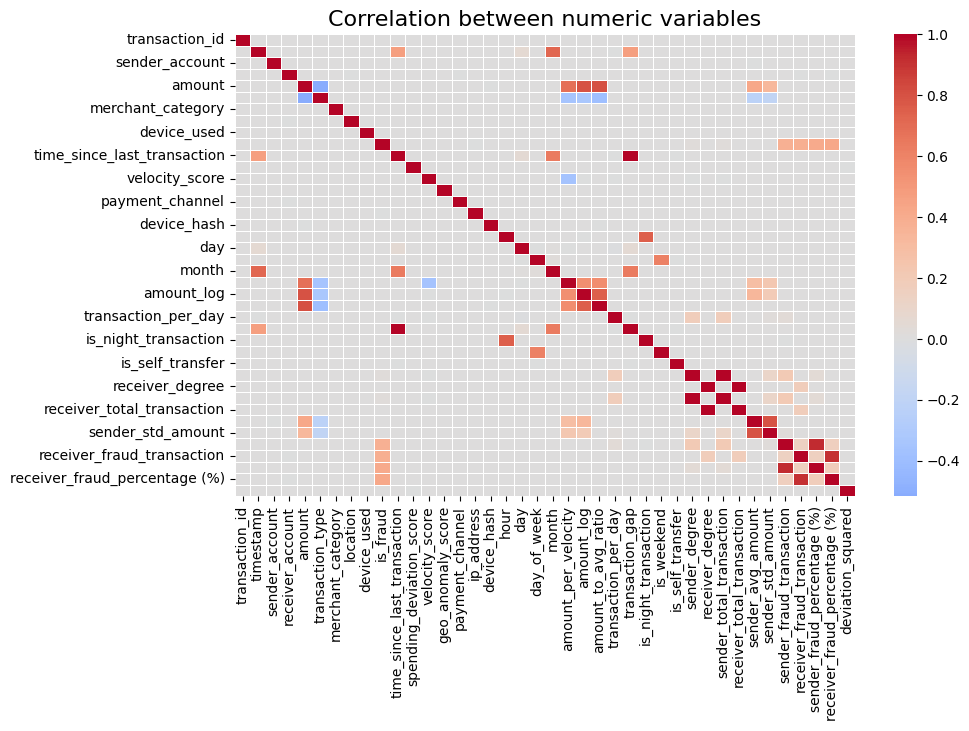

In [46]:
correlation_matrix = df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix,annot=False,cmap='coolwarm',center=0,linewidths=0.5,cbar=True)
plt.title("Correlation between numeric variables",fontsize=16)
plt.show()

In [47]:
# import os

# dest = os.getcwd() + '/dataset'
# os.makedirs(
#     dest, exist_ok=True
# )

# df.to_csv(dest + '/financial_fraud_detection_dataset.csv')

In [48]:
# import os
# import pandas as pd

# dest = os.getcwd() + '/dataset/financial_fraud_detection_dataset.csv' 
# df = pd.read_csv(dest)
# df.describe()

In [49]:
# df.drop(columns=['Unnamed: 0', 'timestamp'], inplace=True)
df.drop(columns=['timestamp'], inplace=True)

In [50]:
df_majority = df[df['is_fraud'] == 0]
df_minority = df[df['is_fraud'] == 1]

df_majority_downsampled = df_majority.sample(n=2*len(df_minority), random_state=36)
df_balanced = pd.concat([df_majority_downsampled, df_minority])
df_balanced.shape

(538659, 39)

In [51]:
from sklearn.model_selection import train_test_split

y = df_balanced['is_fraud']
X = df_balanced.drop(columns=['is_fraud'])


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=36, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=1/8, random_state=36, stratify=y_train)
X_train.head()

,transaction_id,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,time_since_last_transaction,spending_deviation_score,...,receiver_degree,sender_total_transaction,receiver_total_transaction,sender_avg_amount,sender_std_amount,sender_fraud_transaction,receiver_fraud_transaction,sender_fraud_percentage (%),receiver_fraud_percentage (%),deviation_squared
1812489,1003738,418739,429741,215.06,1,1,2,2,-4240.553492,1.00,...,6,5,6,399.164000,752.353433,0.0,0.0,0.00,0.00,1.0000
4337326,3781059,336473,756995,1261.79,0,5,0,1,-3887.919654,-0.28,...,9,6,9,343.151667,460.218645,1.0,1.0,16.67,11.11,0.0784
2292504,1531755,850110,650409,87.30,0,6,0,3,-5558.457235,0.84,...,1,8,1,250.686250,379.568053,4.0,1.0,50.00,100.00,0.7056
4564107,4030518,412055,673083,8.39,2,3,7,3,-4094.274384,-0.48,...,9,8,9,245.526250,170.642460,0.0,0.0,0.00,0.00,0.2304
4499707,3959678,477033,94321,1417.79,0,3,6,3,1540.065888,0.59,...,2,4,2,704.302500,695.945537,0.0,0.0,0.00,0.00,0.3481


In [52]:
len(X_train), len(y_train), len(X_test), len(y_test)

(377061, 377061, 107732, 107732)

In [53]:
X_train.shape, X_test.shape, X_val.shape

((377061, 38), (107732, 38), (53866, 38))

In [54]:
import sklearn
print(sklearn.__version__)

1.2.2


In [55]:
from xgboost import XGBClassifier

scale_pos_weight = y_train[y_train==1].count() / y_train[y_train==0].count()
xgb_model = XGBClassifier(n_estimators=300,
                        objective='binary:logistic',
                        tree_method='hist',
                        max_depth=12, 
                        learning_rate=0.05, 
                        reg_lambda=3.6,
                        reg_alpha=3.6,
                        scale_pos_weight=scale_pos_weight,
                        eval_metric=['aucpr'],
                        verbosity=2,  
                        subsample=0.8,
                        device='cuda',
                        n_jobs=-1)

print("Training model ...")
eval_set=[(X_train, y_train),(X_val, y_val)]
xgb_model.fit(X_train, y_train,
             eval_set=eval_set,
             verbose=50)
print("Training complete!")

Training model ...
[0]	validation_0-aucpr:0.96112	validation_1-aucpr:0.96064
[50]	validation_0-aucpr:0.97866	validation_1-aucpr:0.97536
[100]	validation_0-aucpr:0.98725	validation_1-aucpr:0.97562
[150]	validation_0-aucpr:0.99266	validation_1-aucpr:0.97523
[200]	validation_0-aucpr:0.99684	validation_1-aucpr:0.97504
[250]	validation_0-aucpr:0.99901	validation_1-aucpr:0.97455
[299]	validation_0-aucpr:0.99972	validation_1-aucpr:0.97434
Training complete!


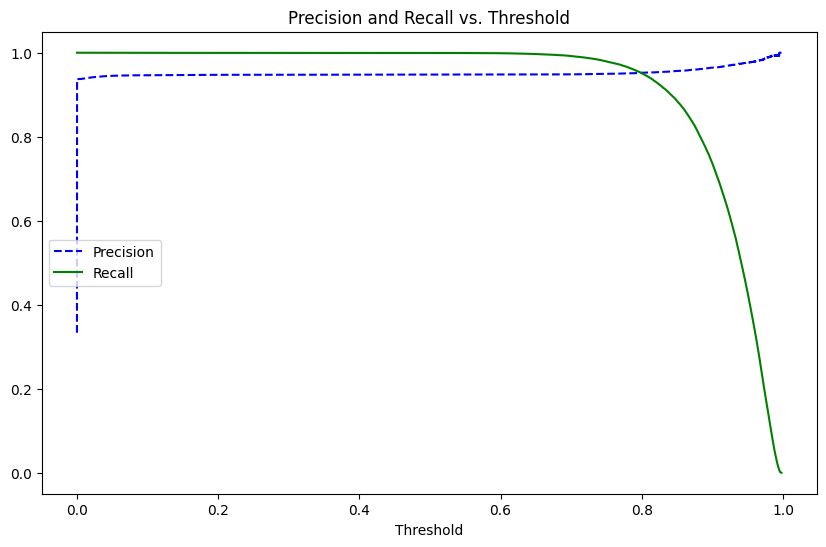

In [56]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.xlabel('Threshold')
plt.legend(loc='center left')
plt.title('Precision and Recall vs. Threshold')
plt.show()

In [57]:
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score

#Evaluate
y_pred_proba = xgb_model.predict_proba(X_test)[: , 1]
print(classification_report(y_test, (y_pred_proba > 0.5).astype(int)))
print(f"AP: {average_precision_score(y_test, y_pred_proba):.4f}")

              precision    recall  f1-score   support

         0.0       1.00      0.97      0.99     71821
         1.0       0.95      1.00      0.97     35911

    accuracy                           0.98    107732
   macro avg       0.97      0.99      0.98    107732
weighted avg       0.98      0.98      0.98    107732

AP: 0.9734


AUC-ROC: 0.9912


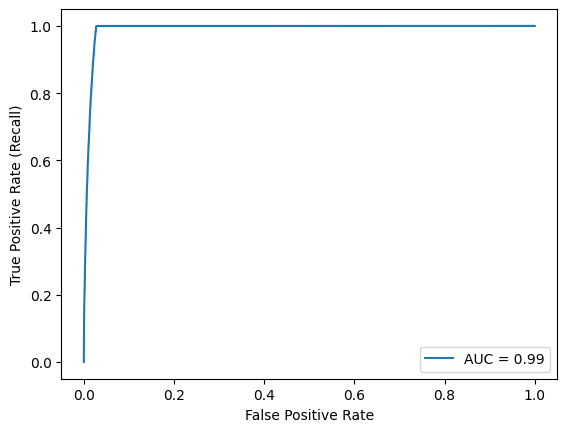

In [58]:
from sklearn.metrics import roc_curve, roc_auc_score


# Calculate AUC-ROC
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC: {auc_score:.4f}")

# Plot the curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

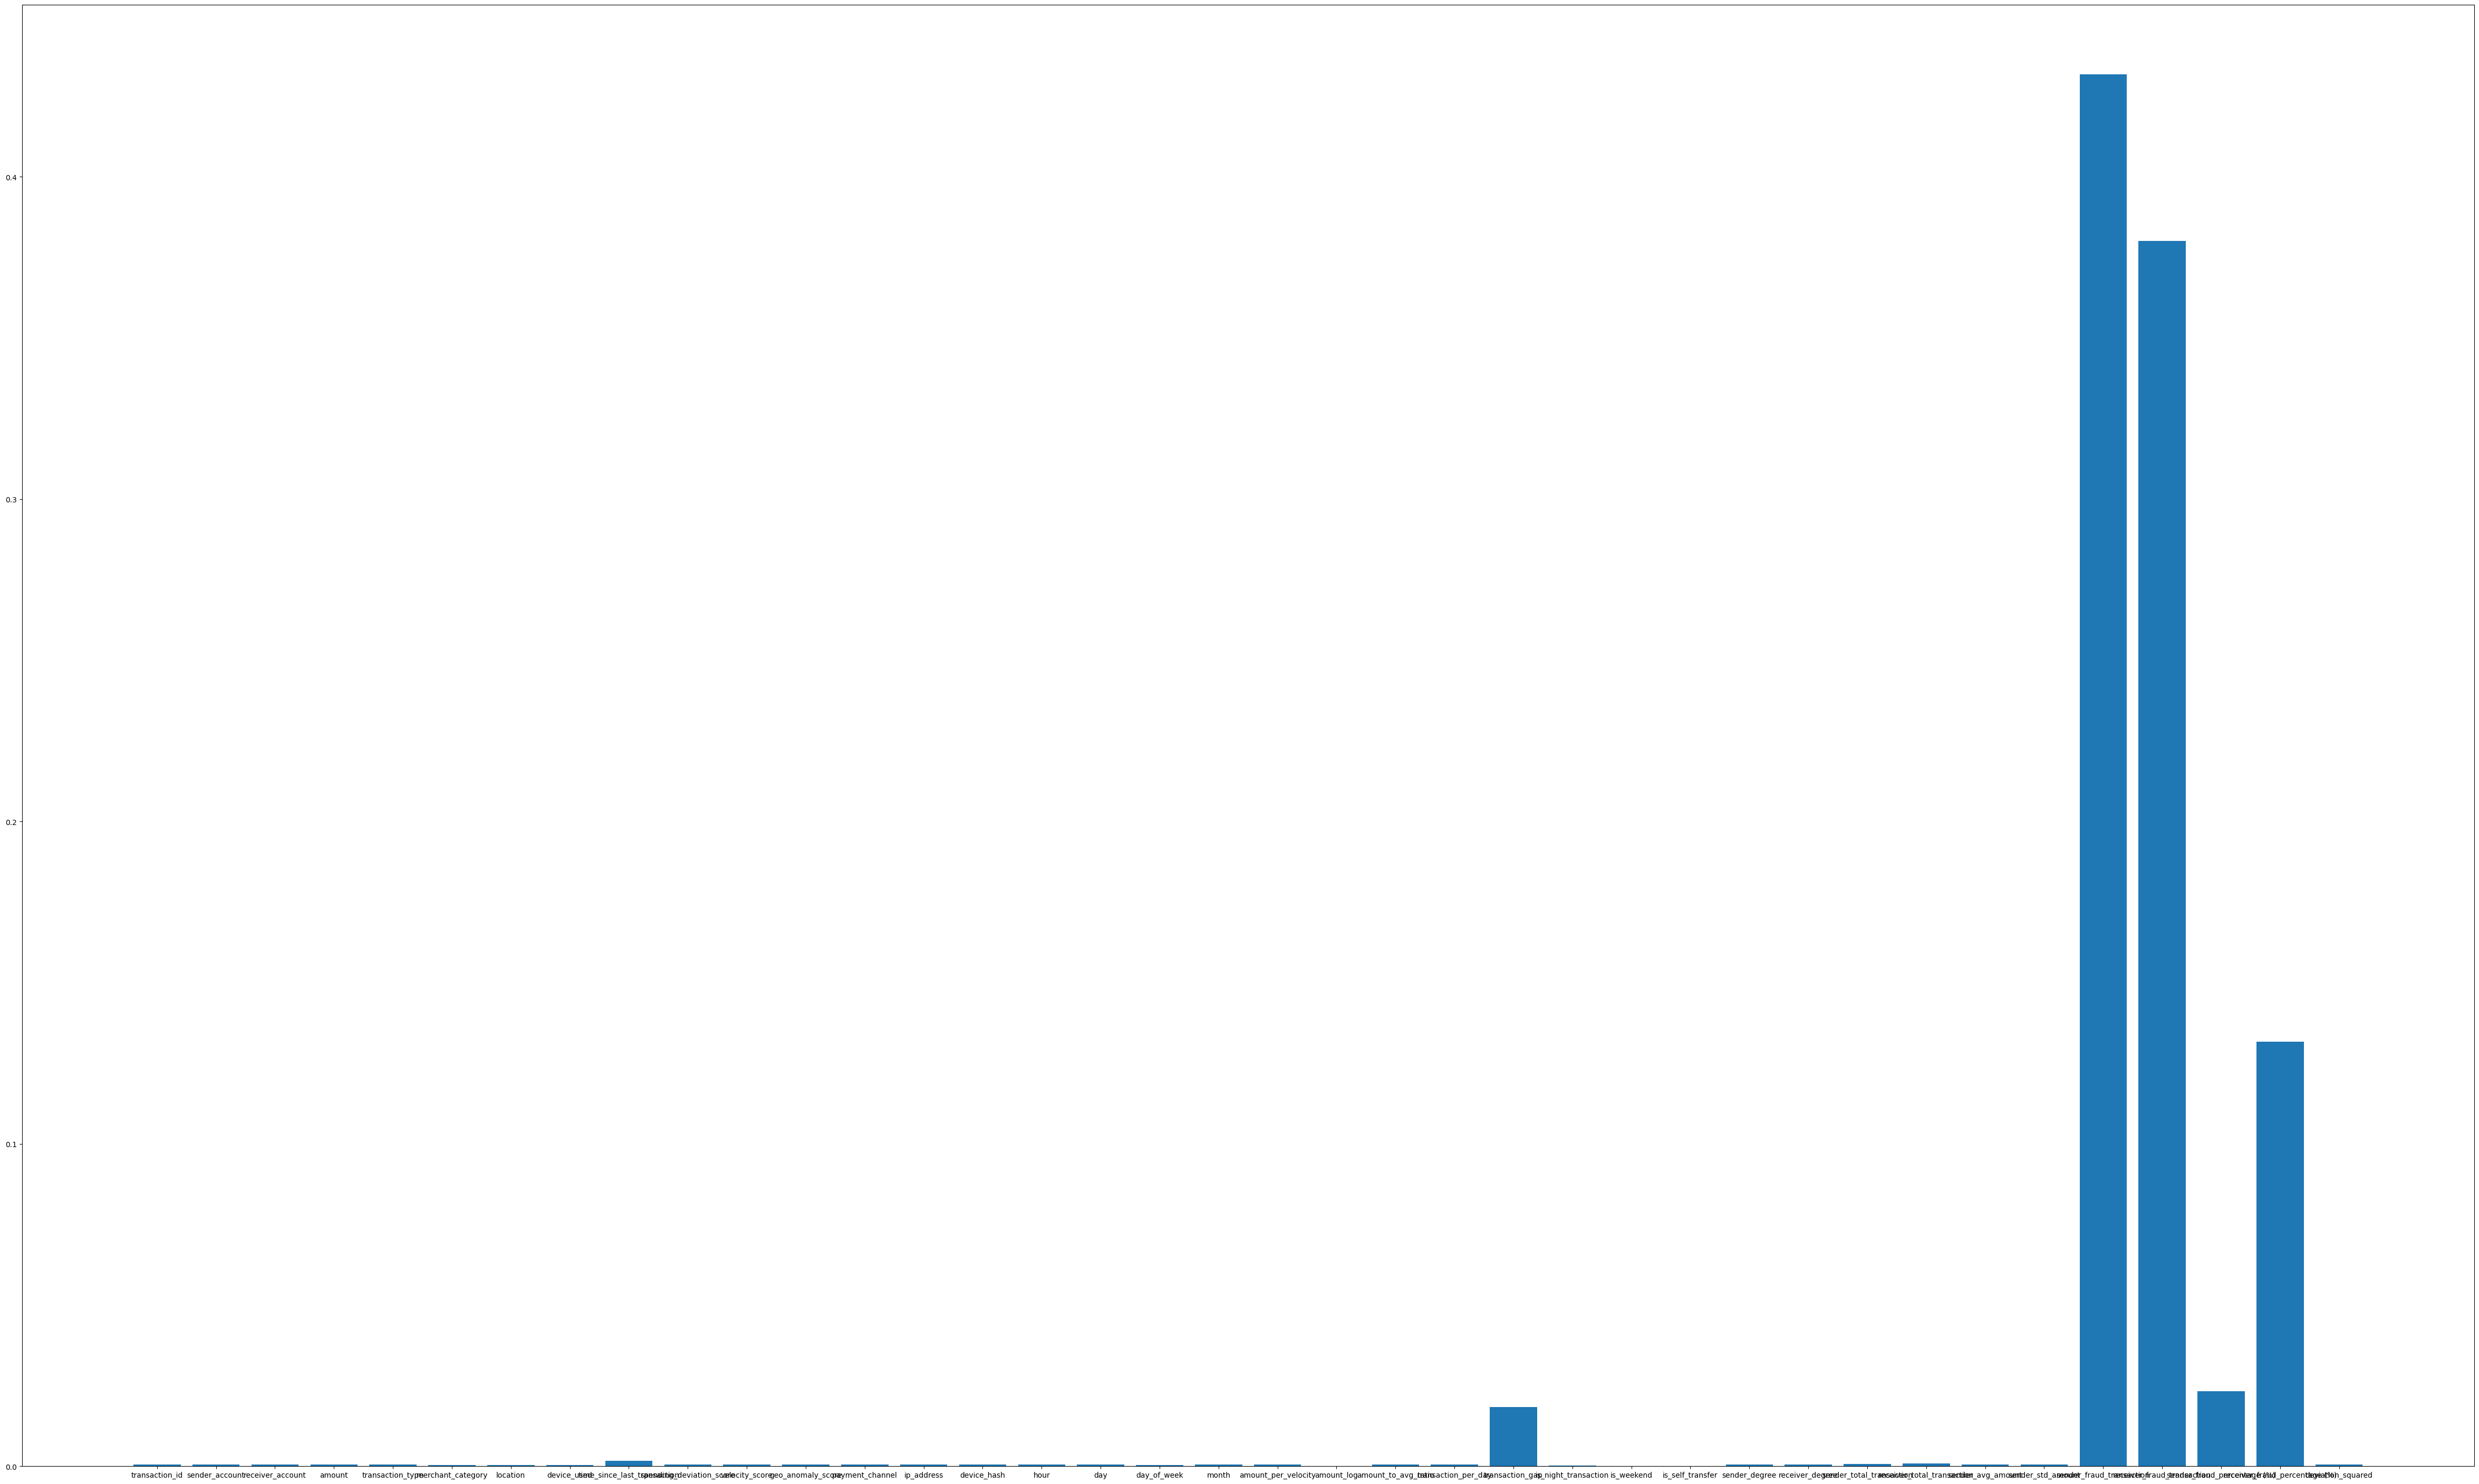

In [59]:
plt.figure(figsize=(60,36))
plt.bar(X.columns.tolist(), xgb_model.feature_importances_)
plt.show()

In [60]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

X_train_mlp, X_test_mlp, y_train_mlp, y_test_mlp = train_test_split(X, y, test_size=0.2, random_state=36, stratify=y)

# Standard Scaler is needed for MLP model
scaler = StandardScaler()
scaler.fit(X_train_mlp)
X_train_mlp, X_test_mlp = scaler.transform(X_train_mlp), scaler.transform(X_test_mlp)

mlp_model = MLPClassifier(hidden_layer_sizes=(36, 72, 36), 
                          learning_rate='adaptive', 
                          learning_rate_init=0.01,
                          max_iter=30,
                          random_state=36,
                          early_stopping=True,
                          validation_fraction=0.1,
                         verbose=True)

print("Training...")
mlp_model.fit(X=X_train_mlp, y=y_train_mlp)
print("Train completed!")
                          

Training...
Iteration 1, loss = 0.08314299
Validation score: 0.977096
Iteration 2, loss = 0.07927609
Validation score: 0.977073
Iteration 3, loss = 0.07907044
Validation score: 0.977096
Iteration 4, loss = 0.07903047
Validation score: 0.977096
Iteration 5, loss = 0.07870634
Validation score: 0.977096
Iteration 6, loss = 0.07876073
Validation score: 0.977096
Iteration 7, loss = 0.07842122
Validation score: 0.977096
Iteration 8, loss = 0.07791062
Validation score: 0.977096
Iteration 9, loss = 0.07699988
Validation score: 0.977096
Iteration 10, loss = 0.07565911
Validation score: 0.977444
Iteration 11, loss = 0.07472891
Validation score: 0.977699
Iteration 12, loss = 0.07423737
Validation score: 0.978280
Iteration 13, loss = 0.07384044
Validation score: 0.978465
Iteration 14, loss = 0.07361449
Validation score: 0.977537
Iteration 15, loss = 0.07328135
Validation score: 0.978558
Iteration 16, loss = 0.07310843
Validation score: 0.977862
Iteration 17, loss = 0.07321471
Validation score: 0.9

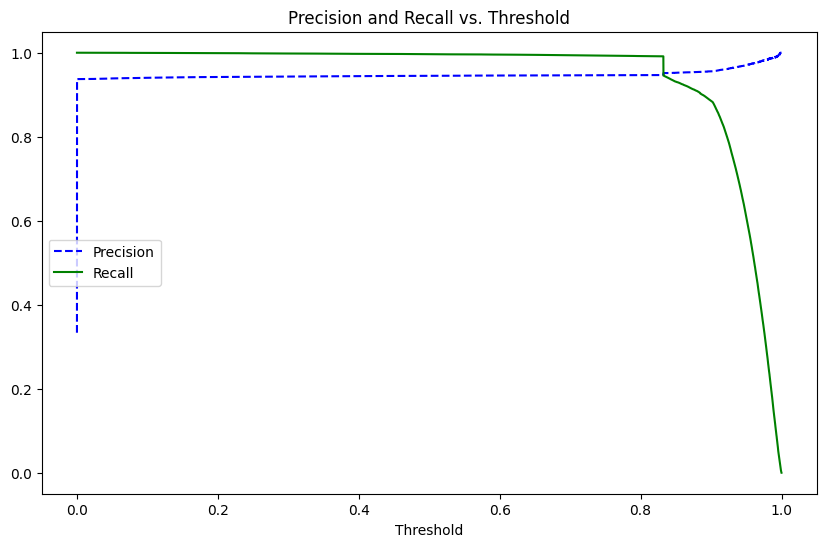

In [61]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_pred_proba = mlp_model.predict_proba(X_test_mlp)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test_mlp, y_pred_proba)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.xlabel('Threshold')
plt.legend(loc='center left')
plt.title('Precision and Recall vs. Threshold')
plt.show()

In [62]:
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score

#Evaluate
y_pred_proba = mlp_model.predict_proba(X_test_mlp)[:, 1]
print(y_pred_proba)
print(classification_report(y_test_mlp, (y_pred_proba > 0.5).astype(int)))
print(f"AP: {average_precision_score(y_test_mlp, y_pred_proba):.4f}")

[9.61281440e-01 4.60260768e-15 9.28284576e-01 ... 9.95849112e-01
 2.60357455e-22 1.42696456e-42]
              precision    recall  f1-score   support

         0.0       1.00      0.97      0.98     71821
         1.0       0.94      1.00      0.97     35911

    accuracy                           0.98    107732
   macro avg       0.97      0.98      0.98    107732
weighted avg       0.98      0.98      0.98    107732

AP: 0.9740


AUC-ROC: 0.9913


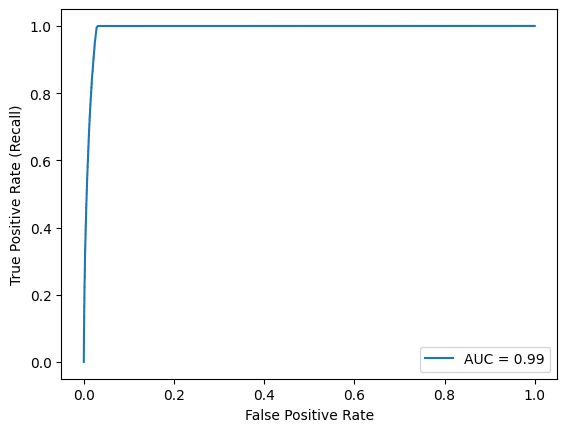

In [63]:
from sklearn.metrics import roc_curve, roc_auc_score


# Calculate AUC-ROC
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC: {auc_score:.4f}")

# Plot the curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [64]:
# RandomForest don't need validation dataset
X_test = pd.concat([X_test, X_val])
y_test = pd.concat([y_test, y_val])

In [65]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=300,
                                 max_depth=12,
                                 min_samples_split=16,
                                 class_weight='balanced',
                                  verbose=2,
                                 n_jobs=-1)

print("Training...")
rf_model.fit(X_train, y_train)
print("Train completed!")

Training...
building tree 1 of 300
building tree 2 of 300
building tree 3 of 300
building tree 4 of 300


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.


building tree 5 of 300
building tree 6 of 300
building tree 7 of 300
building tree 8 of 300
building tree 9 of 300
building tree 10 of 300
building tree 11 of 300
building tree 12 of 300
building tree 13 of 300
building tree 14 of 300
building tree 15 of 300
building tree 16 of 300
building tree 17 of 300
building tree 18 of 300
building tree 19 of 300
building tree 20 of 300
building tree 21 of 300
building tree 22 of 300
building tree 23 of 300
building tree 24 of 300
building tree 25 of 300
building tree 26 of 300
building tree 27 of 300
building tree 28 of 300
building tree 29 of 300
building tree 30 of 300
building tree 31 of 300
building tree 32 of 300
building tree 33 of 300
building tree 34 of 300
building tree 35 of 300
building tree 36 of 300
building tree 37 of 300
building tree 38 of 300
building tree 39 of 300


[Parallel(n_jobs=-1)]: Done  33 tasks      | elapsed:    9.2s


building tree 40 of 300
building tree 41 of 300
building tree 42 of 300
building tree 43 of 300
building tree 44 of 300
building tree 45 of 300
building tree 46 of 300
building tree 47 of 300
building tree 48 of 300
building tree 49 of 300
building tree 50 of 300
building tree 51 of 300
building tree 52 of 300
building tree 53 of 300
building tree 54 of 300
building tree 55 of 300
building tree 56 of 300
building tree 57 of 300
building tree 58 of 300
building tree 59 of 300
building tree 60 of 300
building tree 61 of 300
building tree 62 of 300
building tree 63 of 300
building tree 64 of 300
building tree 65 of 300
building tree 66 of 300
building tree 67 of 300
building tree 68 of 300
building tree 69 of 300
building tree 70 of 300
building tree 71 of 300
building tree 72 of 300
building tree 73 of 300
building tree 74 of 300
building tree 75 of 300
building tree 76 of 300
building tree 77 of 300
building tree 78 of 300
building tree 79 of 300
building tree 80 of 300
building tree 81

[Parallel(n_jobs=-1)]: Done 154 tasks      | elapsed:   39.2s


building tree 159 of 300
building tree 160 of 300
building tree 161 of 300
building tree 162 of 300
building tree 163 of 300
building tree 164 of 300
building tree 165 of 300
building tree 166 of 300
building tree 167 of 300
building tree 168 of 300
building tree 169 of 300
building tree 170 of 300
building tree 171 of 300
building tree 172 of 300
building tree 173 of 300
building tree 174 of 300
building tree 175 of 300
building tree 176 of 300
building tree 177 of 300
building tree 178 of 300
building tree 179 of 300
building tree 180 of 300
building tree 181 of 300
building tree 182 of 300
building tree 183 of 300
building tree 184 of 300
building tree 185 of 300
building tree 186 of 300
building tree 187 of 300
building tree 188 of 300
building tree 189 of 300
building tree 190 of 300
building tree 191 of 300
building tree 192 of 300
building tree 193 of 300
building tree 194 of 300
building tree 195 of 300
building tree 196 of 300
building tree 197 of 300
building tree 198 of 300


[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  1.3min finished


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:    0.2s
[Parallel(n_jobs=4)]: Done 154 tasks      | elapsed:    0.8s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    1.6s finished


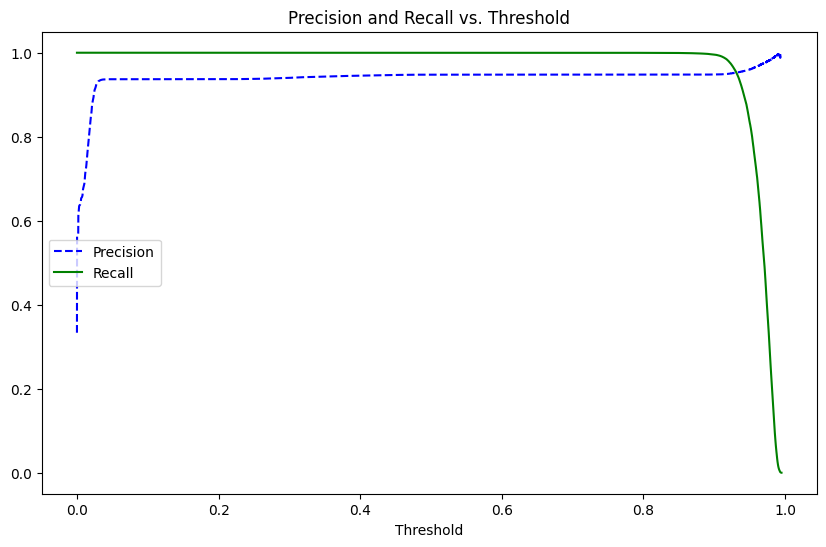

In [66]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_pred_proba = rf_model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.xlabel('Threshold')
plt.legend(loc='center left')
plt.title('Precision and Recall vs. Threshold')
plt.show()

In [67]:
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score

#Evaluate
y_pred_proba = rf_model.predict_proba(X_test)[: , 1]
print(classification_report(y_test, (y_pred_proba > 0.5).astype(int)))
print(f"AP: {average_precision_score(y_test, y_pred_proba):.4f}")

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:    0.2s
[Parallel(n_jobs=4)]: Done 154 tasks      | elapsed:    0.9s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    1.7s finished


              precision    recall  f1-score   support

         0.0       1.00      0.97      0.99    107732
         1.0       0.95      1.00      0.97     53866

    accuracy                           0.98    161598
   macro avg       0.97      0.99      0.98    161598
weighted avg       0.98      0.98      0.98    161598

AP: 0.9743


AUC-ROC: 0.9915


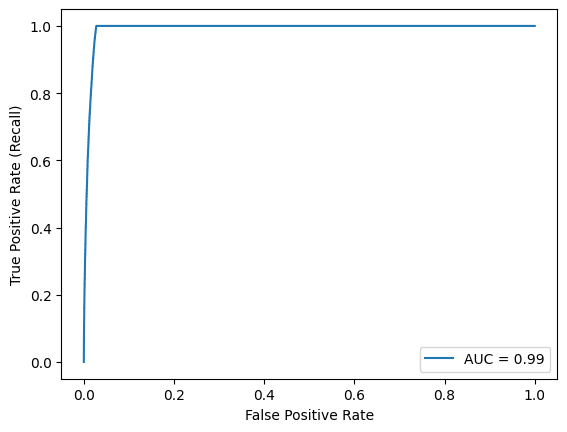

In [68]:
from sklearn.metrics import roc_curve, roc_auc_score


# Calculate AUC-ROC
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC: {auc_score:.4f}")

# Plot the curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [69]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
scaler.fit(X_train)
X_train, X_test = scaler.transform(X_train), scaler.transform(X_test)

iso_model = IsolationForest(
    n_estimators=300,
    max_samples=128,
    max_features=3,
    contamination=y_train.mean(),
    bootstrap=False,
    verbose=2,
    random_state=36,
    n_jobs=-1
)

print("Training...")
iso_model.fit(X_train)
print("Training completed!")

Training...
Building estimator 1 of 75 for this parallel run (total 300)...
Building estimator 1 of 75 for this parallel run (total 300)...
Building estimator 1 of 75 for this parallel run (total 300)...
Building estimator 1 of 75 for this parallel run (total 300)...
Building estimator 2 of 75 for this parallel run (total 300)...
Building estimator 2 of 75 for this parallel run (total 300)...
Building estimator 2 of 75 for this parallel run (total 300)...
Building estimator 2 of 75 for this parallel run (total 300)...
Building estimator 3 of 75 for this parallel run (total 300)...
Building estimator 3 of 75 for this parallel run (total 300)...
Building estimator 3 of 75 for this parallel run (total 300)...
Building estimator 3 of 75 for this parallel run (total 300)...
Building estimator 4 of 75 for this parallel run (total 300)...
Building estimator 4 of 75 for this parallel run (total 300)...
Building estimator 4 of 75 for this parallel run (total 300)...
Building estimator 4 of 75 f

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.


Building estimator 14 of 75 for this parallel run (total 300)...
Building estimator 13 of 75 for this parallel run (total 300)...
Building estimator 15 of 75 for this parallel run (total 300)...
Building estimator 14 of 75 for this parallel run (total 300)...
Building estimator 15 of 75 for this parallel run (total 300)...
Building estimator 16 of 75 for this parallel run (total 300)...
Building estimator 14 of 75 for this parallel run (total 300)...
Building estimator 15 of 75 for this parallel run (total 300)...
Building estimator 16 of 75 for this parallel run (total 300)...
Building estimator 17 of 75 for this parallel run (total 300)...
Building estimator 15 of 75 for this parallel run (total 300)...
Building estimator 17 of 75 for this parallel run (total 300)...
Building estimator 18 of 75 for this parallel run (total 300)...
Building estimator 16 of 75 for this parallel run (total 300)...
Building estimator 16 of 75 for this parallel run (total 300)...
Building estimator 17 of 

[Parallel(n_jobs=4)]: Done   4 out of   4 | elapsed:    1.0s finished


Training completed!


In [70]:
y_pred_iso = iso_model.predict(X_test)
print(np.unique(y_pred_iso, return_counts=True))
y_pred_iso = np.where(y_pred_iso == -1, 1, 0)

(array([-1,  1]), array([ 53752, 107846]))


In [71]:
print(classification_report(y_test, y_pred_iso))
print(f"AP: {average_precision_score(y_test, y_pred_iso):.4f}")

              precision    recall  f1-score   support

         0.0       0.75      0.75      0.75    107732
         1.0       0.50      0.50      0.50     53866

    accuracy                           0.66    161598
   macro avg       0.62      0.62      0.62    161598
weighted avg       0.66      0.66      0.66    161598

AP: 0.4144


In [72]:
from sklearn.metrics import precision_recall_curve, average_precision_score, auc
score = iso_model.decision_function(X_test)
ap_score = average_precision_score(y_test, -score)
print(f"Average Precision: {ap_score:.4f}")

precision, recall, _ = precision_recall_curve(y_test, -score)
auprc = auc(recall, precision)
print(f"AUPRC: {auprc:.4f}")

Average Precision: 0.5026
AUPRC: 0.5026


AUC-ROC: 0.6812


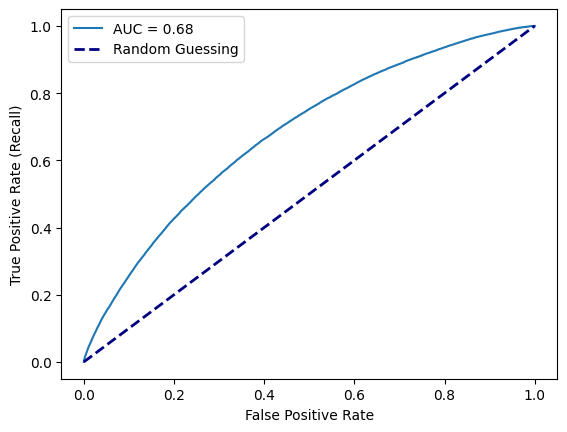

In [73]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate AUC-ROC
auc_score = roc_auc_score(y_test, -score)
print(f"AUC-ROC: {auc_score:.4f}")

# Plot the curve
fpr, tpr, _ = roc_curve(y_test, -score)
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()